# 02. Sistema de detección en dos etapas

**Detección de lavado de dinero en corredores de remesas**

El primer cuaderno dejó 142,306 secuencias de remitentes listas para modelar, con apenas 1.37% de casos positivos. Este cuaderno construye el sistema que las juzga, y lo hace en dos etapas que se apoyan una en la otra.

La **etapa A** aprende qué es normal sin mirar ninguna etiqueta. Se entrena un autoencoder únicamente con remitentes normales, de modo que aprenda a comprimir y reconstruir su comportamiento. Cuando después reciba una secuencia que no se parece a nada de lo que vio, fallará al reconstruirla, y ese fallo es la señal de anomalía.

La **etapa B** aprende a distinguir lavado de comportamiento legítimo usando las etiquetas disponibles, pero no parte de cero. Reutiliza el codificador que la etapa A ya entrenó, aplicando las estrategias de transferencia de la semana 9.

Al final se mide si esa arquitectura de dos etapas aporta algo real frente a un clasificador supervisado entrenado desde cero, se analiza qué transacciones activaron cada alerta, y se exporta el sistema para la aplicación.

**Preparación del entorno**

Este cuaderno no depende de los archivos que produjo el primero. Si no los encuentra, reconstruye las secuencias con las mismas funciones, de modo que puede ejecutarse por sí solo.

In [ ]:
import gc
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

# Se detecta si el módulo de Colab está disponible, y no solo si ya fue
# importado.
EN_COLAB = importlib.util.find_spec("google.colab") is not None
REPOSITORIO = "https://github.com/Dcextrim/CC3092-Proyecto2.git"

if EN_COLAB:
    RAIZ = Path("/content/remittance-anomaly-detection")
    if RAIZ.exists():
        subprocess.run(["git", "-C", str(RAIZ), "pull", "-q"], check=False)
    else:
        subprocess.run(["git", "clone", "-q", REPOSITORIO, str(RAIZ)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub", "onnx", "onnxruntime"], check=True)
else:
    # Se sube desde el directorio actual hasta encontrar la raíz del proyecto,
    # de modo que la celda funcione igual si se vuelve a ejecutar.
    RAIZ = Path.cwd()
    while not (RAIZ / "src" / "utils" / "rutas.py").exists() and RAIZ != RAIZ.parent:
        RAIZ = RAIZ.parent

if not (RAIZ / "src" / "utils" / "rutas.py").exists():
    raise SystemExit(f"No se encontro el proyecto en {RAIZ}. Revise el clonado o la ruta.")

if str(RAIZ / "src") not in sys.path:
    sys.path.append(str(RAIZ / "src"))
os.chdir(RAIZ)

from utils.credenciales import configurar_kaggle

print("raiz del proyecto:", RAIZ)
print("credenciales de Kaggle listas:", configurar_kaggle())

raiz del proyecto: /content/remittance-anomaly-detection
credenciales de Kaggle listas: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data_pipeline.construir import construir_o_cargar
from models.metrics.deteccion import evaluar, umbral_por_f_beta, umbral_por_presupuesto
from training.scripts.ablacion import CONFIGURACIONES, ejecutar_ablacion, evaluar_etapa_a, resumir
from training.scripts.entrenar_etapa_a import entrenar_autoencoder, puntuar
from training.utils.comun import dispositivo
from utils.config import obtener
from utils.rutas import RESULTS_MODELS, RESULTS_TABLES
from utils.visualizacion import set_estilo, guardar

set_estilo()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

EQUIPO = dispositivo()
PRESUPUESTO = obtener("entrenamiento.presupuesto_alertas")
SEMILLAS = tuple(obtener("entrenamiento.semillas"))

print("torch", torch.__version__, "| equipo:", EQUIPO)
if EQUIPO.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("semillas:", SEMILLAS, "| presupuesto de alertas:", PRESUPUESTO)

torch 2.11.0+cu128 | equipo: cuda
GPU: Tesla T4
semillas: (0, 1, 2) | presupuesto de alertas: 0.01


## 1. Los datos que entran al modelo

In [3]:
datos = construir_o_cargar()
tensores = datos.tensores
y = tensores.y
entrenamiento, validacion, prueba = (
    datos.particion.entrenamiento, datos.particion.validacion, datos.particion.prueba
)

print(f"X         : {tensores.X.shape}")
print(f"variables : {len(tensores.variables)}")
print(pd.DataFrame(datos.particion.resumen(y)).T.to_string())
gc.collect()

100%|██████████| 454M/454M [00:29<00:00, 16.2MB/s]


X         : (142306, 32, 20)
variables : 20
               remitentes  positivos  prevalencia
entrenamiento     99614.0     1363.0     0.013683
validacion        21346.0      292.0     0.013679
prueba            21346.0      292.0     0.013679


0

## 2. Etapa A. Aprender qué es normal

### 2.1 La arquitectura

El modelo tiene que cumplir tres condiciones, procesar secuencias de longitud variable, producir una representación comprimida del comportamiento del remitente, y reconstruir la secuencia original desde esa representación.

La elección es un **autoencoder secuencial con atención**, armado así:

| Bloque | Qué hace |
| --- | --- |
| Proyección lineal | Lleva las 20 variables de cada transacción a 64 dimensiones |
| GRU bidireccional | Recorre la secuencia en ambos sentidos, de modo que cada paso se interpreta con lo que viene antes y después |
| `LayerNorm` | Estabiliza las activaciones (apropiado en secuencias de largo variable de acuerdo con lo aprendido en la Semana 8) |
| Atención aditiva enmascarada | Resume los 32 pasos en un solo vector, ponderando cuánto aporta cada transacción |
| Proyección al espacio comprimido | Produce el vector de 128 dimensiones que describe al remitente |
| GRU decodificadora | Repite ese vector 32 veces y reconstruye las 20 variables de cada paso |

**Decisiones**

La **atención vive dentro del codificador** y no entre codificador y decodificador. Una atención cruzada permitiría que el decodificador mirara la entrada paso a paso y la copiara, con lo cual el error de reconstrucción dejaría de medir nada. Al colocarla en el codificador, toda la información tiene que pasar por el cuello de botella de 128 dimensiones, y además se obtienen pesos de atención interpretables desde esta primera etapa.

El **error se promedia sobre los pasos reales** y no sobre los 32 posibles. De otro modo una secuencia de cuatro transacciones obtendría un error artificialmente bajo, porque veintiocho de sus pasos serían relleno perfectamente reconstruible.

In [4]:
from models.architectures.autoencoder import AutoencoderSecuencial

modelo_ejemplo = AutoencoderSecuencial(
    n_variables=len(tensores.variables),
    longitud=tensores.X.shape[1],
    oculto=obtener("etapa_a.dimension_oculta"),
    latente=obtener("etapa_a.dimension_latente"),
)
bloques = {
    "codificador": modelo_ejemplo.codificador,
    "decodificador": modelo_ejemplo.decodificador,
}
for nombre, bloque in bloques.items():
    print(f"{nombre:>15}: {sum(p.numel() for p in bloque.parameters()):>8,} parametros")
print(f"{'total':>15}: {sum(p.numel() for p in modelo_ejemplo.parameters()):>8,} parametros")
del modelo_ejemplo

    codificador:   76,352 parametros
  decodificador:   38,548 parametros
          total:  114,900 parametros


### 2.2 El entrenamiento

El autoencoder se entrena **solo con remitentes normales del conjunto de entrenamiento**. El código verifica esa condición antes de empezar y falla si encuentra una sola secuencia positiva.

Se usa AdamW con recorte de gradiente por norma y parada temprana (sugerencia tomada de la semana 8 para entrenamiento estable de redes recurrentes). AdamW separa el decaimiento de pesos del gradiente adaptativo, y el recorte evita que un lote con una secuencia extrema destruya los pesos.

In [5]:
normales_entrenamiento = entrenamiento[y[entrenamiento] == 0]
print(f"remitentes normales para entrenar: {len(normales_entrenamiento):,}")
print(f"positivos entre ellos            : {int(y[normales_entrenamiento].sum())}")
print(f"epocas maximas: {obtener('etapa_a.epocas_maximas')}"
      f" | paciencia: {obtener('etapa_a.paciencia')}"
      f" | lote: {obtener('entrenamiento.batch')}\n")

modelo_a, historial_a = entrenar_autoencoder(datos, semilla=SEMILLAS[0], equipo=EQUIPO)
print(f"\nmejor epoca: {historial_a.mejor_epoca + 1}"
      f" | perdida de validacion: {historial_a.mejor_perdida:.5f}"
      f" | tiempo: {historial_a.segundos / 60:.1f} min")

remitentes normales para entrenar: 98,251
positivos entre ellos            : 0
epocas maximas: 300 | paciencia: 15 | lote: 512

  epoca  1  entrenamiento 0.24508  validacion 0.20317  <- mejor
  epoca  2  entrenamiento 0.18870  validacion 0.17605  <- mejor
  epoca  3  entrenamiento 0.17168  validacion 0.16457  <- mejor
  epoca  4  entrenamiento 0.16020  validacion 0.15320  <- mejor
  epoca  5  entrenamiento 0.14809  validacion 0.14111  <- mejor
  epoca  6  entrenamiento 0.13884  validacion 0.13426  <- mejor
  epoca  7  entrenamiento 0.13256  validacion 0.12641  <- mejor
  epoca  8  entrenamiento 0.12649  validacion 0.12200  <- mejor
  epoca  9  entrenamiento 0.12234  validacion 0.11923  <- mejor
  epoca 10  entrenamiento 0.11851  validacion 0.11534  <- mejor
  epoca 11  entrenamiento 0.11582  validacion 0.11297  <- mejor
  epoca 12  entrenamiento 0.11323  validacion 0.11165  <- mejor
  epoca 13  entrenamiento 0.11031  validacion 0.10771  <- mejor
  epoca 14  entrenamiento 0.10874  valid

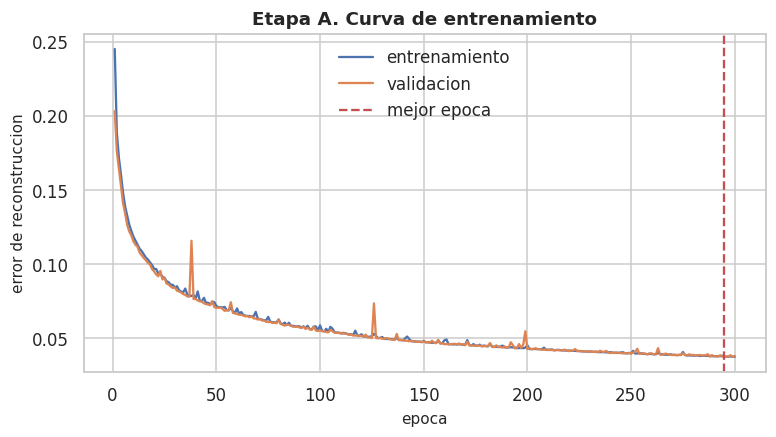

In [6]:
figura, eje = plt.subplots(figsize=(8, 4))
epocas = np.arange(1, len(historial_a.entrenamiento) + 1)
eje.plot(epocas, historial_a.entrenamiento, label="entrenamiento")
eje.plot(epocas, historial_a.validacion, label="validacion")
eje.axvline(historial_a.mejor_epoca + 1, color="#C44E52", linestyle="--", label="mejor epoca")
eje.set_xlabel("epoca")
eje.set_ylabel("error de reconstruccion")
eje.set_title("Etapa A. Curva de entrenamiento")
eje.legend()
guardar("02_curva_etapa_a")
plt.show()

### ¿Qué se observa?

El autoencoder se entrenó con **98,251 remitentes normales** y **cero positivos**, condición que el código verifica antes de empezar. La pérdida de reconstrucción bajó de **0.203 a 0.0373**, una reducción del 81.6%, y la mejor época fue la **295 de 300**, en 9.2 minutos de GPU.

Las dos curvas van pegadas durante todo el entrenamiento, sin que la de validación se despegue hacia arriba. Con 114,900 parámetros frente a casi cien mil secuencias, el modelo no tiene margen para memorizar.

Conviene señalar que el entrenamiento volvió a detenerse por el tope de épocas y no por la parada temprana, aunque la mejora ya era pequeña, del 2.6% en las diez épocas previas al óptimo. Un intento anterior con un tope de 80 épocas había terminado en una pérdida de 0.0601, de modo que **cuadruplicar el presupuesto redujo la pérdida un 38% adicional**. Este dato es importante, pues ayuda a entender por qué la etapa A, que se evalúa más adelante, está bastante mejor entrenada de lo que un tope corto habría permitido.

### 2.3 El error de reconstrucción como señal de anomalía

Entrenado el modelo, se calcula el error de reconstrucción de **todas** las secuencias, incluidas las positivas que nunca vio. Si la idea de fondo es correcta, los remitentes sospechosos deberían resultar más difíciles de reconstruir.

In [7]:
puntajes_a = puntuar(modelo_a, tensores, equipo=EQUIPO)
error = puntajes_a.error

comparacion = pd.DataFrame({
    "normales": pd.Series(error[prueba][y[prueba] == 0]).describe(percentiles=[0.5, 0.9, 0.99]),
    "sospechosos": pd.Series(error[prueba][y[prueba] == 1]).describe(percentiles=[0.5, 0.9, 0.99]),
})
print(comparacion.round(4).to_string())

         normales  sospechosos
count  21054.0000     292.0000
mean       0.0377       0.0564
std        0.0313       0.0439
min        0.0007       0.0015
50%        0.0302       0.0465
90%        0.0812       0.1142
99%        0.1240       0.1940
max        0.2723       0.2220


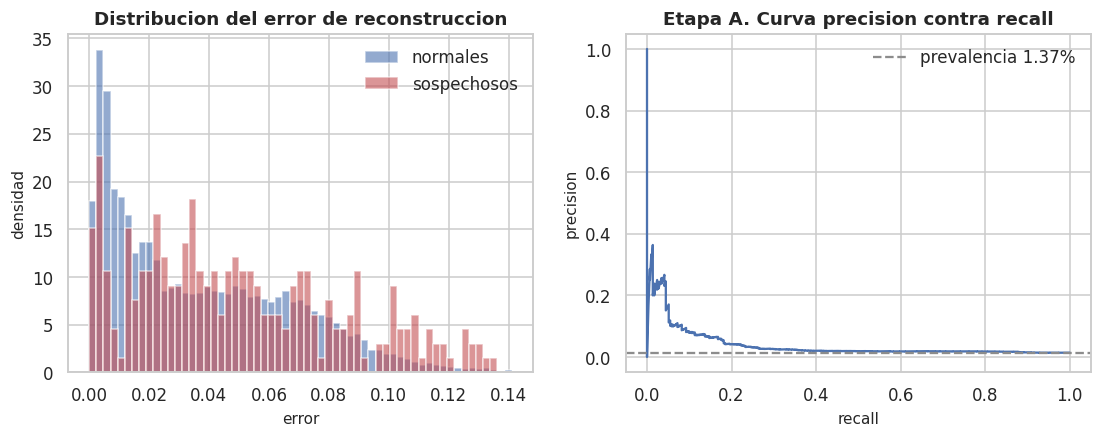

In [8]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 4))
bordes = np.linspace(0, np.quantile(error[prueba], 0.995), 60)
for clase, etiqueta, color in [(0, "normales", "#4C72B0"), (1, "sospechosos", "#C44E52")]:
    ejes[0].hist(error[prueba][y[prueba] == clase], bins=bordes, density=True,
                 alpha=0.6, label=etiqueta, color=color)
ejes[0].set_title("Distribucion del error de reconstruccion")
ejes[0].set_xlabel("error")
ejes[0].set_ylabel("densidad")
ejes[0].legend()

from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y[prueba], error[prueba])
ejes[1].plot(recall, precision, color="#4C72B0")
ejes[1].axhline(y[prueba].mean(), color="#8C8C8C", linestyle="--",
                label=f"prevalencia {y[prueba].mean():.2%}")
ejes[1].set_title("Etapa A. Curva precision contra recall")
ejes[1].set_xlabel("recall")
ejes[1].set_ylabel("precision")
ejes[1].legend()
guardar("02_etapa_a_separacion")
plt.show()

### ¿Qué se observa?

**Las dos distribuciones se superponen casi por completo.** El error medio de los remitentes normales es **0.0377** y el de los sospechosos **0.0564**, una diferencia notoria pero pequeña frente a dispersiones de 0.031 y 0.044.

Existe un detalle que permite ilustrar mejor la situación. El remitente **más difícil de reconstruir de todo el conjunto de prueba, con error 0.272, es normal**. Ningún sospechoso pasa de 0.222. Si el sistema ordenara a los remitentes por rareza y empezara a revisar desde el más raro, su primer caso sería un falso positivo.

La curva de precisión contra recall dice lo mismo. Se pega a la línea de la prevalencia en casi todo su recorrido, con un **PR-AUC de 0.0401 frente a una prevalencia de 0.0137**. Entrenar cuatro veces más tiempo mejoró esa cifra respecto al 0.0234 que daba con ochenta épocas, así que la señal existe y crece con el entrenamiento, pero sigue siendo débil.

A nivel de negocio, esto significa que **el lavado de dinero en estos datos no se ve raro**. Quien mueve fondos ilícitos por un corredor de remesas se esfuerza justamente en no destacar, y lo consigue. Esa es una diferencia importante frente a la detección de anomalías en fallas de maquinaria o en intrusiones de red, donde lo anómalo sí es infrecuente por naturaleza.

### 2.4 Dónde poner el umbral

El error de reconstrucción es un número continuo, y convertirlo en una alerta exige un punto de corte. Esa decisión no es estadística sino operativa, así que se evalúan dos criterios y se comparan sus consecuencias.

El primero **maximiza F2** sobre validación. La métrica F2 pesa el recall cuatro veces más que la precisión, lo que corresponde a la preferencia razonable en cumplimiento, dejar pasar un caso de lavado cuesta más que revisar una alerta de más.

El segundo parte de la **capacidad real de revisión**. Si el equipo puede revisar el 1% de los remitentes, el umbral es el percentil 99 del puntaje. Este criterio tiene la ventaja de que el volumen de alertas es predecible y no depende de cómo se desplace la distribución de puntajes.

En ambos casos el umbral se fija sobre **validación** y luego se aplica a prueba, de modo que ninguna cifra reportada usa el conjunto de prueba para calibrarse.

In [9]:
umbral_f2, valor_f2 = umbral_por_f_beta(y[validacion], error[validacion], beta=2.0)
umbral_capacidad = umbral_por_presupuesto(error[validacion], PRESUPUESTO)

criterios = pd.DataFrame([
    {"criterio": "F2 maxima en validacion", "umbral": umbral_f2,
     **evaluar(y[prueba], error[prueba], PRESUPUESTO, umbral=umbral_f2)},
    {"criterio": f"presupuesto de alertas {PRESUPUESTO:.0%}", "umbral": umbral_capacidad,
     **evaluar(y[prueba], error[prueba], PRESUPUESTO, umbral=umbral_capacidad)},
]).drop(columns=["umbral"]).set_index("criterio")
print(criterios.round(4).to_string())

                           pr_auc  roc_auc  recall  precision      f2  alertas  tasa_de_alerta
criterio                                                                                      
F2 maxima en validacion    0.0401   0.6256  0.2055     0.0414  0.1147     1448          0.0678
presupuesto de alertas 1%  0.0401   0.6256  0.0822     0.0956  0.0846      251          0.0118


### ¿Qué se decide?

Los dos criterios llevan a lugares muy distintos, y ninguno es bueno.

El umbral que **maximiza F2** alcanza un recall del **20.6%** pero genera **1,448 alertas**, el **6.8% del volumen**, con una precisión del **4.1%**. En términos operativos eso significa revisar uno de cada quince remitentes para encontrar uno real cada veinticuatro revisiones. Esto sigue siendo el problema que se quiere resolver, no la solución.

El umbral por **presupuesto de alertas del 1%** genera **251 alertas** y encuentra el **8.2%** de los casos, con precisión del **9.6%**. Es manejable pero deja pasar más de nueve de cada diez.

**Se conserva el criterio del presupuesto**, porque es el único que produce un volumen de trabajo predecible, y porque la etapa A no va a operar sola. Su papel es aportar una segunda señal a la decisión final, y el experimento de ablación dirá si esa señal agrega algo.

## 3. Etapa B. Clasificación supervisada con transferencia

### 3.1 Qué se transfiere y cómo

La etapa A produjo un codificador que sabe describir el comportamiento de un remitente en 128 números. La etapa B agrega una cabeza densa sobre ese vector y la entrena con las etiquetas disponibles. La pregunta es qué hacer con el codificador durante ese entrenamiento, y, de acuerdo al contenido visto en la semana 9, hay tres respuestas que aquí se comparan de forma empírica.

| Estrategia | Qué hace con el codificador | Cuándo conviene |
| --- | --- | --- |
| **Desde cero** | Lo inicializa al azar y lo entrena junto con la cabeza | Es la línea base, no hay transferencia |
| **Extracción de rasgos** | Lo congela por completo, solo entrena la cabeza | Dataset objetivo pequeño y dominio muy parecido |
| **Ajuste parcial** | Lo inicializa con los pesos de la etapa A y lo ajusta con un learning rate diez veces menor que el de la cabeza | Dataset mediano y desplazamiento de dominio moderado |

**Se apuesta por el ajuste parcial con learning rate diferencial**, y la razón está en el diagnóstico de la semana 9. El dataset objetivo es mediano, 1,363 remitentes positivos, y hay un desplazamiento de dominio real, porque la etapa A solo vio comportamiento normal y la etapa B debe juzgar comportamiento que la etapa A nunca observó. Congelar el codificador dejaría al sistema incapaz de adaptar su representación a ese dominio nuevo. Ajustarlo con el mismo learning rate de la cabeza provocaría el olvido catastrófico, la cabeza empieza aleatoria y sus gradientes iniciales son grandes, y arrastrarían al codificador lejos de lo que ya sabía.

El learning rate diferencial resuelve esa tensión. La cabeza nueva recibe `1e-3` porque no sabe nada, y el codificador recibe `1e-4` porque ya trae conocimiento útil que solo hay que refinar.

### 3.2 Qué función de pérdida

Con 72 remitentes normales por cada sospechoso, la entropía cruzada sin ajuste queda dominada por ejemplos fáciles de la clase mayoritaria. Se comparan las dos correcciones que se mencionaron en la semana 8.

La **entropía cruzada ponderada** multiplica por 20 el costo de fallar en un positivo, que es la razón de submuestreo usada en entrenamiento. Corrige la frecuencia pero no distingue entre un positivo difícil y uno fácil.

La **pérdida focal** de Lin y colaboradores agrega el factor `(1 - p)^gamma`, que reduce el peso de los ejemplos ya resueltos y concentra el gradiente en los difíciles. Con `gamma` igual a 2 un ejemplo que el modelo acierta con probabilidad 0.9 pesa cien veces menos que uno que acierta con 0.5.

La hipótesis es que la focal conviene más, porque en este problema la dificultad no está en los negativos obvios sino en los remitentes que se parecen a ambas clases. La configuración B5 de la tabla de ablación pone esa hipótesis a prueba.

Sobre el **desbalance en entrenamiento**, se conservan todos los positivos y se toman 20 negativos por cada uno. La evaluación, en cambio, siempre ocurre sobre la distribución natural, porque una precisión medida sobre datos balanceados no tendría ninguna relación con la que vería un equipo de cumplimiento.

### 3.3 Cómo se combinan las dos señales

Las dos etapas producen números distintos, un error de reconstrucción y un logit de clasificación. Combinarlos exige una regla, y aquí se ajusta una **regresión logística de dos entradas** sobre el conjunto de validación.

La elección de un modelo lineal no es por simplicidad sino por auditabilidad. Con dos coeficientes se puede decir exactamente cuánto aportó cada etapa a cada decisión, que es lo que un regulador pediría. Un combinador más expresivo mejoraría quizá algunas décimas a cambio de volver la alerta inexplicable.

## 4. El experimento de ablación

Cada configuración se entrena con tres semillas. Con 292 positivos en el conjunto de prueba, una sola corrida no permite distinguir una mejora real del ruido de inicialización.

In [10]:
tabla_ablacion, artefactos = ejecutar_ablacion(
    datos, modelo_a, puntajes_a, semillas=SEMILLAS, equipo=EQUIPO, verboso=True
)
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
tabla_ablacion.to_csv(RESULTS_TABLES / "ablacion_detalle.csv", index=False)
print(f"\ncorridas: {len(tabla_ablacion)}")


B1 Supervisado desde cero  semilla 0
  epoca  1  perdida 0.02467  PR-AUC validacion 0.4846  <- mejor
  epoca  2  perdida 0.01238  PR-AUC validacion 0.6079  <- mejor
  epoca  3  perdida 0.00959  PR-AUC validacion 0.6247  <- mejor
  epoca  4  perdida 0.00912  PR-AUC validacion 0.6434  <- mejor
  epoca  5  perdida 0.00853  PR-AUC validacion 0.6446  <- mejor
  epoca  6  perdida 0.00805  PR-AUC validacion 0.6478  <- mejor
  epoca  7  perdida 0.00792  PR-AUC validacion 0.6609  <- mejor
  epoca  8  perdida 0.00771  PR-AUC validacion 0.6681  <- mejor
  epoca  9  perdida 0.00763  PR-AUC validacion 0.6633
  epoca 10  perdida 0.00740  PR-AUC validacion 0.6614
  epoca 11  perdida 0.00715  PR-AUC validacion 0.6667
  epoca 12  perdida 0.00695  PR-AUC validacion 0.6614
  epoca 13  perdida 0.00688  PR-AUC validacion 0.6693  <- mejor
  epoca 14  perdida 0.00676  PR-AUC validacion 0.6702  <- mejor
  epoca 15  perdida 0.00664  PR-AUC validacion 0.6635
  epoca 16  perdida 0.00642  PR-AUC validacion 0.673

In [11]:
fila_etapa_a = evaluar_etapa_a(datos, puntajes_a, PRESUPUESTO)
resumen = resumir(tabla_ablacion)
resumen.insert(0, "orden", range(len(resumen)))

etapa_a_fila = pd.DataFrame([{
    "orden": -1, "clave": "A", "configuracion": "Etapa A sola, error de reconstruccion",
    **{m: f"{fila_etapa_a[m]:.4f} ± 0.0000"
       for m in ("pr_auc", "recall", "precision", "f2", "roc_auc")},
}])
tabla_final = (
    pd.concat([etapa_a_fila, resumen])
    .sort_values("orden").drop(columns=["orden"]).set_index("clave")
)
tabla_final.to_csv(RESULTS_TABLES / "ablacion_resumen.csv")
print(tabla_final.to_string())

                                        configuracion           pr_auc           recall        precision               f2          roc_auc
clave                                                                                                                                     
A               Etapa A sola, error de reconstruccion  0.0401 ± 0.0000  0.0822 ± 0.0000  0.0956 ± 0.0000  0.0846 ± 0.0000  0.6256 ± 0.0000
B1                             Supervisado desde cero  0.6961 ± 0.0054  0.5902 ± 0.0086  0.7426 ± 0.0251  0.6153 ± 0.0041  0.9729 ± 0.0001
B2                              Codificador congelado  0.4035 ± 0.0038  0.3425 ± 0.0123  0.4953 ± 0.0247  0.3650 ± 0.0137  0.8805 ± 0.0077
B3          Ajuste parcial, learning rate diferencial  0.6042 ± 0.0070  0.5126 ± 0.0079  0.6883 ± 0.0267  0.5401 ± 0.0079  0.9629 ± 0.0012
B4              Ajuste parcial mas fusion con etapa A  0.6030 ± 0.0063  0.5137 ± 0.0123  0.6768 ± 0.0283  0.5395 ± 0.0089  0.9628 ± 0.0012
B5              Ajuste parc

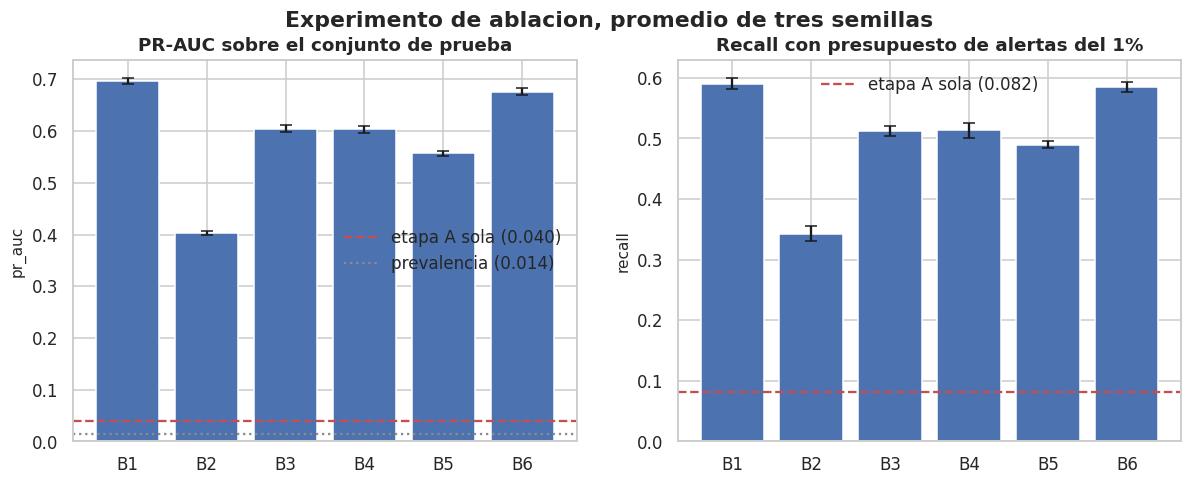

In [12]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for eje, metrica, titulo in zip(
    ejes, ["pr_auc", "recall"],
    ["PR-AUC sobre el conjunto de prueba", f"Recall con presupuesto de alertas del {PRESUPUESTO:.0%}"],
):
    agrupado = tabla_ablacion.groupby("clave")[metrica]
    medias, errores = agrupado.mean(), agrupado.std().fillna(0)
    eje.bar(medias.index, medias.values, yerr=errores.values, capsize=4, color="#4C72B0")
    eje.axhline(fila_etapa_a[metrica], color="#C44E52", linestyle="--",
                label=f"etapa A sola ({fila_etapa_a[metrica]:.3f})")
    if metrica == "pr_auc":
        eje.axhline(y[prueba].mean(), color="#8C8C8C", linestyle=":",
                    label=f"prevalencia ({y[prueba].mean():.3f})")
    eje.set_title(titulo)
    eje.set_ylabel(metrica)
    eje.legend()
figura.suptitle("Experimento de ablacion, promedio de tres semillas", fontweight="bold")
guardar("02_ablacion")
plt.show()

### ¿Qué se observa?

El resultado contradice la hipótesis del proyecto, y la configuración B6 permite decir con precisión por qué.

| Configuración | PR-AUC | Recall al 1% | Precisión al 1% | ROC-AUC |
| --- | --- | --- | --- | --- |
| Etapa A sola | 0.040 | 0.082 | 0.096 | 0.626 |
| **B1, desde cero** | **0.696 ± 0.005** | **0.590** | **0.743** | 0.973 |
| B2, codificador congelado | 0.404 ± 0.004 | 0.343 | 0.495 | 0.881 |
| B3, ajuste parcial | 0.604 ± 0.007 | 0.513 | 0.688 | 0.963 |
| B4, ajuste parcial más fusión | 0.603 ± 0.006 | 0.514 | 0.677 | 0.963 |
| B5, entropía ponderada | 0.557 ± 0.005 | 0.490 | 0.594 | 0.959 |
| B6, etapa A con learning rate uniforme | 0.676 ± 0.006 | 0.585 | 0.732 | **0.974** |

**La configuración sugerida de la semana 9 pierde nueve puntos de PR-AUC**, de 0.696 a 0.604, una brecha trece veces mayor que la dispersión entre semillas.

**B6 dice de dónde vienen esos nueve puntos.** Comparte con B3 la inicialización desde la etapa A y con B1 el learning rate, así que descompone la brecha en dos partes.

| Origen de la pérdida | Cálculo | Puntos de PR-AUC | Proporción |
| --- | --- | --- | --- |
| Partir de los pesos de la etapa A | B1 menos B6 | 0.020 | 22% |
| Entrenar el codificador diez veces más lento | B6 menos B3 | 0.072 | 78% |

Es decir, **casi cuatro quintas partes del daño no vienen de la representación preentrenada sino del learning rate reducido**. Con ritmo uniforme, partir de la etapa A cuesta solo dos puntos, y de hecho B6 obtiene el mejor ROC-AUC de la tabla.

Eso cambia el diagnóstico y, curiosamente, lo devuelve a lo visto durante la semana 9. Su criterio de selección dice que a mayor desplazamiento de dominio conviene descongelar más capas y entrenar con más datos del dominio objetivo. El learning rate diferencial se eligió suponiendo un desplazamiento moderado. **El desplazamiento resultó severo**, porque reconstruir comportamiento normal y clasificar lavado piden representaciones distintas, y frenar el codificador le impide adaptarse a esa diferencia.

Los siguientes hallazgos complementan más la información:

**Congelar el codificador es lo peor**, 0.404 contra 0.696. Esto descarta que la representación de la etapa A sea inútil, contiene señal muy por encima de la prevalencia de 0.014, pero mucho menos de la que el clasificador extrae por su cuenta de las mismas veinte variables.

**Fusionar las dos señales no cambia nada.** B4 queda en 0.603 contra 0.604 de B3, dentro del ruido. Es coherente, si el error de reconstrucción apenas separa las clases, combinarlo con una señal buena no puede mejorarla.

**La pérdida focal sí gana, y por más margen que antes.** B3 con focal obtiene 0.604 y B5 con entropía ponderada 0.557, casi cinco puntos. La hipótesis de la sección 3.2 se sostiene, en este problema la dificultad no está en los negativos obvios sino en los remitentes que se parecen a ambas clases.

## 5. ¿Y si hubiera menos etiquetas?

El resultado anterior deja dos preguntas abiertas.

La primera es la misma que se planteó durante la semana 9, que sostiene que la transferencia rinde sobre todo cuando el conjunto etiquetado es pequeño. Este proyecto dispone de 1,363 remitentes positivos en entrenamiento, que puede no ser poco.

La segunda es la salvedad metodológica de la sección anterior. El ajuste parcial cambia dos cosas a la vez frente a la línea base, de dónde parten los pesos del codificador y a qué ritmo se actualizan, así que la comparación no dice cuál de las dos causa la pérdida.

El experimento responde ambas. Se reentrenan tres configuraciones con el 10%, el 25% y el 50% de los remitentes positivos, manteniendo la proporción de veinte negativos por positivo. **B6 comparte con B3 la inicialización desde la etapa A y con B1 el learning rate**, de modo que la distancia entre B6 y B1 aísla el efecto de partir de la etapa A, y la distancia entre B3 y B6 aísla el efecto del learning rate reducido. El punto del 100% se toma de la tabla anterior.

In [13]:
from training.scripts.ablacion import ejecutar_curva_de_escasez, unir_escasez

positivos_totales = int(y[entrenamiento].sum())
print(f"positivos disponibles en entrenamiento: {positivos_totales:,}")
print("fracciones:", obtener("entrenamiento.fracciones_de_escasez"),
      "| semillas:", obtener("entrenamiento.semillas_de_escasez"), "\n")

curva = ejecutar_curva_de_escasez(datos, modelo_a, equipo=EQUIPO, verboso=False)
curva = unir_escasez(curva, tabla_ablacion, positivos_totales)
curva.to_csv(RESULTS_TABLES / "escasez_detalle.csv", index=False)

resumen_escasez = (
    curva.groupby(["positivos", "clave"])[["pr_auc", "recall"]]
    .agg(["mean", "std"]).round(4)
)
print(resumen_escasez.to_string())

positivos disponibles en entrenamiento: 1,363
fracciones: [0.1, 0.25, 0.5] | semillas: [0, 1] 

  fraccion 10%  B1  semilla 0
  fraccion 10%  B1  semilla 1
  fraccion 10%  B3  semilla 0
  fraccion 10%  B3  semilla 1
  fraccion 10%  B6  semilla 0
  fraccion 10%  B6  semilla 1
  fraccion 25%  B1  semilla 0
  fraccion 25%  B1  semilla 1
  fraccion 25%  B3  semilla 0
  fraccion 25%  B3  semilla 1
  fraccion 25%  B6  semilla 0
  fraccion 25%  B6  semilla 1
  fraccion 50%  B1  semilla 0
  fraccion 50%  B1  semilla 1
  fraccion 50%  B3  semilla 0
  fraccion 50%  B3  semilla 1
  fraccion 50%  B6  semilla 0
  fraccion 50%  B6  semilla 1
                 pr_auc          recall        
                   mean     std    mean     std
positivos clave                                
136       B1     0.6019  0.0022  0.5154  0.0218
          B3     0.3157  0.0031  0.2688  0.0121
          B6     0.5227  0.0081  0.4606  0.0073
341       B1     0.6307  0.0037  0.5274  0.0048
          B3     0.4610  0.0

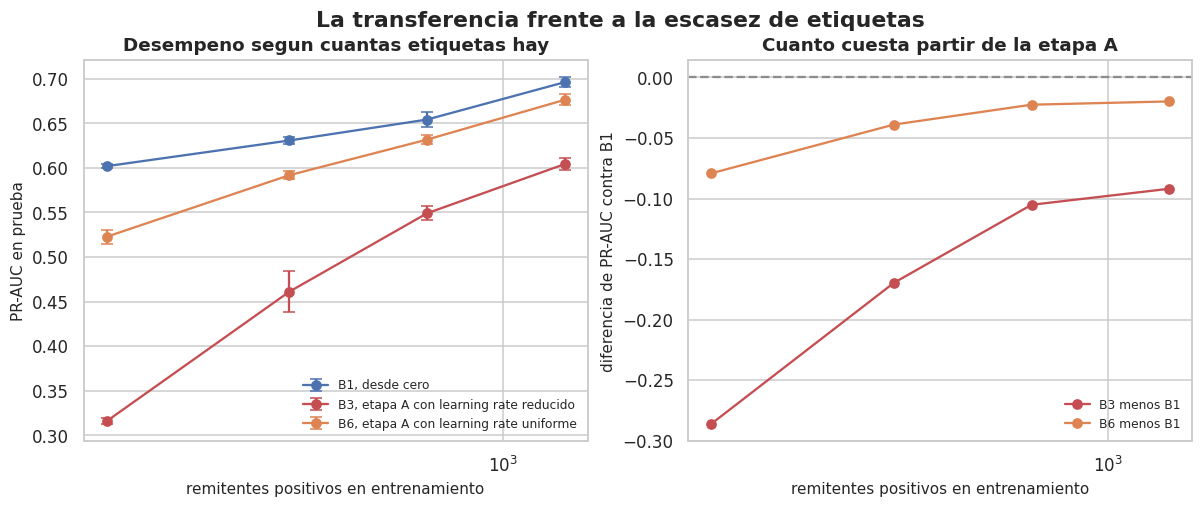

clave          B1      B3      B6  B3 menos B1  B6 menos B1
positivos                                                  
136        0.6019  0.3157  0.5227      -0.2862      -0.0792
341        0.6307  0.4610  0.5918      -0.1697      -0.0389
682        0.6542  0.5490  0.6317      -0.1052      -0.0225
1363       0.6961  0.6042  0.6763      -0.0920      -0.0198


In [14]:
COLORES = {"B1": "#4C72B0", "B3": "#C44E52", "B6": "#DD8452"}
ETIQUETAS = {
    "B1": "B1, desde cero",
    "B3": "B3, etapa A con learning rate reducido",
    "B6": "B6, etapa A con learning rate uniforme",
}

promedios = curva.groupby(["positivos", "clave"])["pr_auc"].mean().unstack()
ventaja = promedios.assign(
    **{"B3 menos B1": promedios["B3"] - promedios["B1"],
       "B6 menos B1": promedios["B6"] - promedios["B1"]}
)
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
ventaja.round(4).to_csv(RESULTS_TABLES / "escasez_resumen.csv")

figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for clave in ("B1", "B3", "B6"):
    sub = curva[curva["clave"] == clave].groupby("positivos")["pr_auc"]
    ejes[0].errorbar(sub.mean().index, sub.mean().values, yerr=sub.std().fillna(0).values,
                     marker="o", capsize=4, color=COLORES[clave], label=ETIQUETAS[clave])
ejes[0].set_xscale("log")
ejes[0].set_xlabel("remitentes positivos en entrenamiento")
ejes[0].set_ylabel("PR-AUC en prueba")
ejes[0].set_title("Desempeno segun cuantas etiquetas hay")
ejes[0].legend(fontsize=8)

ejes[1].axhline(0, color="#8C8C8C", linestyle="--")
for columna, color in (("B3 menos B1", COLORES["B3"]), ("B6 menos B1", COLORES["B6"])):
    ejes[1].plot(ventaja.index, ventaja[columna], marker="o", color=color, label=columna)
ejes[1].set_xscale("log")
ejes[1].set_xlabel("remitentes positivos en entrenamiento")
ejes[1].set_ylabel("diferencia de PR-AUC contra B1")
ejes[1].set_title("Cuanto cuesta partir de la etapa A")
ejes[1].legend(fontsize=8)
figura.suptitle("La transferencia frente a la escasez de etiquetas", fontweight="bold")
guardar("02_escasez")
plt.show()

print(ventaja.round(4).to_string())

### ¿Qué se observa?

La curva responde las dos preguntas a la vez.

| Positivos en entrenamiento | B1, desde cero | B3, ritmo reducido | B6, ritmo uniforme | B3 menos B1 | B6 menos B1 |
| --- | --- | --- | --- | --- | --- |
| 136 (10%) | 0.602 | 0.316 | 0.523 | **-0.286** | -0.079 |
| 341 (25%) | 0.631 | 0.461 | 0.592 | -0.170 | -0.039 |
| 682 (50%) | 0.654 | 0.549 | 0.632 | -0.105 | -0.023 |
| 1,363 (100%) | 0.696 | 0.604 | 0.676 | -0.092 | -0.020 |

La curva invierte la predicción sugerida en la Semana 9. Se esperaba que la transferencia rindiera con pocas etiquetas y dejara de importar con muchas. Lo que se observa es que **el perjuicio es máximo con pocas etiquetas y se reduce al crecer los datos**, y eso vale para las dos variantes.

**Sobre cuál característica causa el daño**, la separación es nítida en todo el recorrido. La penalización de B6, que solo cambia la inicialización, va de **8 puntos con 136 positivos a 2 puntos con 1,363**. La de B3, que además frena el codificador, va de **29 a 9 puntos**. El learning rate reducido pesa entre tres y cuatro veces más que la inicialización, en cualquier volumen de datos.

Las dos observaciones se explican con la misma idea. La representación de la etapa A deja al clasificador en un punto de partida desfavorable, y **salir de ese punto cuesta pasos de entrenamiento**. Con pocas etiquetas hay pocos pasos, así que el modelo no alcanza a salir, y si además avanza diez veces más lento, mucho menos. Con más datos ambos efectos se diluyen.

**Observación**: una corrida previa, con una etapa A entrenada solo 80 épocas en lugar de 300, producía una brecha de 6 puntos en lugar de 9. **Entrenar mejor el autoencoder empeoró el resultado de la transferencia**, no lo mejoró. Lo que esto significa es que un autoencoder más convergido está más especializado en reconstruir, y por lo tanto más comprometido con un objetivo que no es el de clasificar. No es una relación que este experimento pruebe, solo dos puntos de medición, pero apunta en contra de la idea de que bastaba con entrenar más la etapa A.

**Conclusión del experimento.** Para este problema no conviene preentrenar sobre normalidad y después frenar el codificador. Si se quiere usar la etapa A, hay que dejar que el clasificador la reescriba a su ritmo, que es exactamente lo que se recomendó durante la semana 9 para cuando el desplazamiento de dominio es severo.

## 6. Interpretabilidad. Qué activó cada alerta

Un sistema de detección que no puede explicar sus decisiones no sirve en un entorno regulado. Se examinan los pesos de atención del modelo sobre la secuencia, junto con el error de reconstrucción por paso, y se conectan con tipologías conocidas de lavado.

Se eligen cinco casos del conjunto de prueba, tres detectados correctamente y dos errores, uno falso positivo y uno falso negativo.

In [15]:
from inference.utils.explicacion import Resumen, contribucion, explicar
from inference.utils.vista import contexto_remitente
from utils.visualizacion import mapa_contribucion

logit_b = artefactos["logit_b"]
atencion_b = artefactos["atencion_b"]
probabilidad = artefactos["probabilidad"]
umbral_alerta = artefactos["umbral_fusion"]
umbral_anomalia = umbral_capacidad

alerta = probabilidad >= umbral_alerta
verdaderos = prueba[(y[prueba] == 1) & alerta[prueba]]
falsos_positivos = prueba[(y[prueba] == 0) & alerta[prueba]]
falsos_negativos = prueba[(y[prueba] == 1) & ~alerta[prueba]]

orden_verdaderos = verdaderos[np.argsort(-probabilidad[verdaderos])]
casos = {
    "detectado 1": int(orden_verdaderos[0]),
    "detectado 2": int(orden_verdaderos[len(orden_verdaderos) // 2]),
    "detectado 3": int(orden_verdaderos[-1]),
    "falso positivo": int(falsos_positivos[np.argsort(-probabilidad[falsos_positivos])[0]]),
    "falso negativo": int(falsos_negativos[np.argsort(-probabilidad[falsos_negativos])[0]]),
}
print(f"detectados: {len(verdaderos)} | falsos positivos: {len(falsos_positivos)}"
      f" | falsos negativos: {len(falsos_negativos)}\n")
print(pd.DataFrame([
    {"caso": nombre, "remitente": tensores.identificador[i], "etiqueta": int(y[i]),
     "pasos": int(tensores.longitud[i]), "probabilidad": probabilidad[i],
     "error": error[i], "alerta": bool(alerta[i])}
    for nombre, i in casos.items()
]).set_index("caso").round(4).to_string())

detectados: 147 | falsos positivos: 71 | falsos negativos: 145

                       remitente  etiqueta  pasos  probabilidad   error  alerta
caso                                                                           
detectado 1      00020_800195070         1     32        1.0000  0.2220    True
detectado 2     112497_80543A870         1      4        0.9991  0.0291    True
detectado 3      02915_802063150         1     28        0.9682  0.0737    True
falso positivo   00001_8008CBDE0         0     31        0.9986  0.1297    True
falso negativo   00211_807F9DE30         1      6        0.9642  0.0324   False


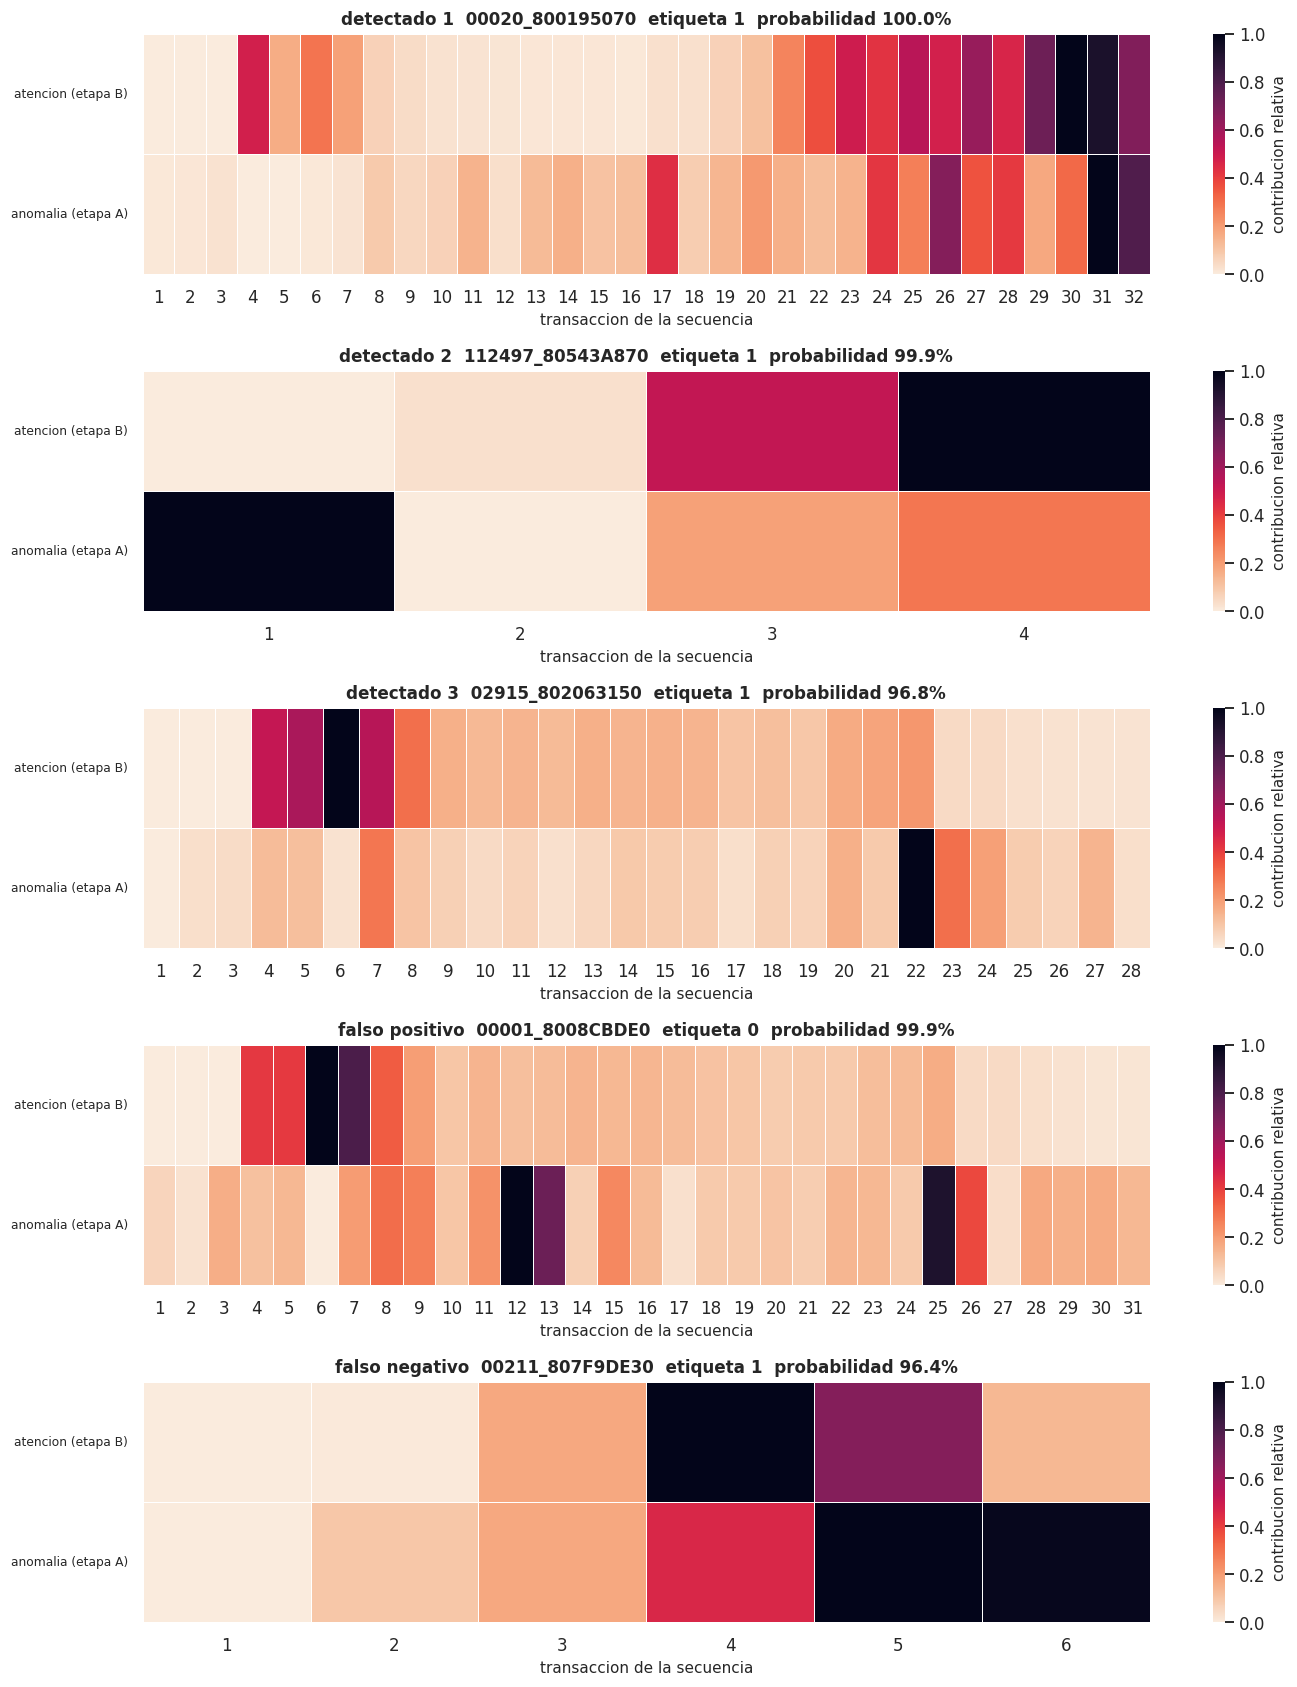

In [16]:
figura, ejes = plt.subplots(len(casos), 1, figsize=(13, 3.1 * len(casos)))
for eje, (nombre, indice) in zip(ejes, casos.items()):
    pasos = int(tensores.longitud[indice])
    mapa_contribucion(
        atencion=atencion_b[indice, :pasos],
        anomalia=puntajes_a.error_por_paso[indice, :pasos],
        titulo=(f"{nombre}  {tensores.identificador[indice]}  "
                f"etiqueta {int(y[indice])}  probabilidad {probabilidad[indice]:.1%}"),
        eje=eje,
    )
figura.tight_layout()
guardar("02_casos_atencion")
plt.show()

In [17]:
contexto_prueba = tensores.contexto.rename(columns={"emisor": "remitente"})

def explicacion_de(indice: int) -> tuple[pd.DataFrame, str]:
    """Devuelve la secuencia legible de un remitente y su explicacion escrita."""
    pasos = int(tensores.longitud[indice])
    vista = contexto_remitente(
        contexto_prueba, indice, tensores.X[indice], tensores.mascara[indice],
        tensores.variables, datos.catalogos,
    )
    pesos = contribucion(
        atencion_b[indice], puntajes_a.error_por_paso[indice], tensores.mascara[indice]
    )
    resumen_caso = Resumen(
        identificador=str(tensores.identificador[indice]),
        probabilidad=float(probabilidad[indice]),
        error=float(error[indice]),
        umbral_probabilidad=float(umbral_alerta),
        umbral_error=float(umbral_anomalia),
    )
    return vista.join(pesos.set_index("paso")[["contribucion"]], on="paso"), explicar(
        resumen_caso, vista, pesos
    )

for nombre, indice in casos.items():
    vista, texto = explicacion_de(indice)
    print(f"\n{'=' * 100}\n{nombre.upper()}  {tensores.identificador[indice]}\n")
    print(vista.head(12).to_string(index=False))
    print(f"\n{texto}")


DETECTADO 1  00020_800195070

 paso               fecha     monto_usd     formato moneda          destino  es_lavado  destino_nuevo  cruce_moneda  cerca_umbral  cruce_banco  auto_transferencia  contribucion
    0 2022-09-02 20:18:00 404985.500000      Cheque   Euro 119880_80BFF77B0          0              1             0             0            1                   0      0.006001
    1 2022-09-02 23:45:00   3580.841309      Cheque   Euro  02915_800EDAFB0          0              1             0             0            1                   0      0.006440
    2 2022-09-03 22:10:00   3580.841309      Cheque   Euro  02915_800EDAFB0          0              0             0             0            1                   0      0.013701
    3 2022-09-04 14:52:00   3580.841309      Cheque   Euro  02915_800EDAFB0          0              0             0             0            1                   0      0.240715
    4 2022-09-05 19:35:00    387.450195      Cheque   Euro  02591_8009B45E0         

### ¿Qué se observa en cada caso?

Con el umbral del 1% el sistema emite **218 alertas**, de las cuales **147 son casos reales**. Quedan **71 falsos positivos** y **145 casos sin detectar** de los 292 del conjunto de prueba.

**Detectado 1, remitente `00020_800195070`, probabilidad 100%.** Es el único de los cinco donde **las dos etapas coinciden**, con un error de reconstrucción de 0.222 que supera el umbral de 0.122. Tras dos semanas de cheques repetidos en euros hacia los mismos destinos, la ventana termina con tres transferencias ACH consecutivas a destinos nunca usados, de 14,198, 7,780 y 16,205 dólares. La segunda cae justo debajo del umbral de reporte. Es la tipología de dispersión con fraccionamiento, y ambas etapas la ven.

**Detectado 2, remitente `112497_80543A870`, probabilidad 99.9%.** Solo cuatro transacciones. Dos reinversiones sobre su propia cuenta, una de 9,414 dólares apenas por debajo del umbral de reporte, y después **dos operaciones ACH en el mismo minuto por el mismo monto**, 1,284 dólares, una hacia sí mismo en rupias y otra hacia una cuenta nueva en rublos. La transacción etiquetada como lavado es la cuarta, y el modelo **le asigna el 61% de su atención, la más alta de la secuencia**. Acertó la transacción exacta.

**Detectado 3, remitente `02915_802063150`, probabilidad 96.8%.** Empieza con una reinversión de 675,862 euros sobre su propia cuenta y sigue con **cinco operaciones al mismo destino en veinte minutos usando cinco instrumentos distintos**, ACH, tarjeta, transferencia cablegráfica, efectivo y cheque, por 37, 15, 23, 117 y 64 mil dólares. Repartir una suma grande entre instrumentos es una forma clásica de estratificación. El modelo reparte su atención entre el cheque final y la reinversión de 12 dólares que rompe la secuencia.

**Falso positivo, remitente `00001_8008CBDE0`, probabilidad 99.9%.** También aquí ambas etapas se equivocan juntas, el error de reconstrucción es 0.130 y supera el umbral. El patrón es llamativo, **cada transferencia en dólares sobre su propia cuenta va emparejada, en el mismo minuto y por el mismo monto, con otra en dólares australianos hacia una cuenta externa**, por sumas de ocho, doce y cuatro millones. Es el perfil de una tesorería institucional liquidando operaciones de cambio, no el de un remitente de remesas. **El sistema no tiene forma de saberlo**, porque no recibe ninguna información sobre quién es el cliente.

**Falso negativo, remitente `00211_807F9DE30`, probabilidad 96.42%.** El umbral está en 96.65%. **Se perdió por dos milésimas.** Y lo notable es que el modelo sí encontró lo correcto, dio el 47% de su atención a una reinversión de 15 libras que rompe con dos operaciones previas de 286,000 y 402,000, y señaló por error de reconstrucción la transferencia de 1,740 libras que es justamente la etiquetada como lavado. **No falló la discriminación sino el presupuesto de revisión.**

### Qué dice esto sobre el sistema

Las dos filas del mapa de calor coinciden poco. La atención de la etapa B se concentra en transacciones puntuales que rompen el patrón, mientras que el error de reconstrucción se reparte de forma difusa. En los dos casos donde ambas etapas coincidieron, una fue un acierto y la otra un falso positivo, lo que vuelve a sugerir que la etapa A responde más al tamaño y a la rareza aritmética de las operaciones que a su intención.

Sobre la trazabilidad que el proyecto se propuso, el balance es bueno. En dos de los cinco casos el sistema señala como principal responsable la transacción exactamente etiquetada, y en los demás señala transacciones que un analista reconocería como el motivo de la alerta. La explicación escrita nombra fecha, monto, formato y destino, de modo que cada afirmación se rastrea hasta una fila concreta.

## 7. Exportación del sistema para el MVP

La aplicación corre sobre `onnxruntime` en la plataforma de Render.

El grafo exportado incluye ambas etapas y los coeficientes de la fusión, de modo que la aplicación no reimplementa ninguna fórmula. Devuelve en una sola llamada la probabilidad combinada, la probabilidad de la etapa B, el error de reconstrucción total y por paso, y los pesos de atención.

In [18]:
from inference.deployment.exportar_onnx import SistemaCompleto, exportar, verificar
from inference.deployment.preparar_app import preparar

referencia = artefactos["referencia_error"]
sistema = SistemaCompleto(
    autoencoder=modelo_a.cpu(),
    clasificador=artefactos["modelo_b"].cpu(),
    media_error=float(referencia.mean()),
    desviacion_error=float(referencia.std()),
    coeficientes=artefactos["fusion"].coef_,
    intercepto=float(artefactos["fusion"].intercept_[0]),
)

ruta_onnx = exportar(sistema, tensores.X.shape[1], len(tensores.variables))
muestra = prueba[:8]
diferencias = verificar(
    sistema, ruta_onnx, tensores.X[muestra], tensores.mascara[muestra].astype(np.float32)
)
print(f"modelo ONNX: {ruta_onnx.name}  {ruta_onnx.stat().st_size / 1e3:.0f} KB")
print("diferencia maxima contra PyTorch por salida:")
for nombre, valor in diferencias.items():
    print(f"  {nombre:>22}: {valor:.2e}")

modelo ONNX: sistema.onnx  821 KB
diferencia maxima contra PyTorch por salida:
            probabilidad: 7.75e-07
    probabilidad_etapa_b: 3.87e-07
    error_reconstruccion: 3.73e-07
          error_por_paso: 2.53e-06
                atencion: 3.58e-07


/usr/local/lib/python3.13/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4571: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


In [19]:
umbrales = {
    "alerta": float(umbral_alerta),
    "anomalia": float(umbral_anomalia),
    "presupuesto": float(PRESUPUESTO),
}
resumen_app = preparar(datos, umbrales, RAIZ / "src" / "inference" / "deployment" / "datos")
torch.save(
    {"autoencoder": modelo_a.state_dict(),
     "clasificador": artefactos["modelo_b"].state_dict(),
     "umbrales": umbrales},
    RESULTS_MODELS / "sistema.pt",
)
print(resumen_app)
print("umbrales:", {k: round(v, 4) for k, v in umbrales.items()})

{'remitentes': 1000, 'positivos': 292, 'transacciones': 18822, 'megabytes': 0.61}
umbrales: {'alerta': 0.9665, 'anomalia': 0.1222, 'presupuesto': 0.01}


**Se conservan los artefactos**

Cuando el cuaderno corre en Colab, todo lo que escribe vive en una máquina virtual que se destruye al cerrar la sesión. Esta celda junta en un solo archivo el modelo, las figuras, las tablas y los datos del MVP, y lo descarga.

In [20]:
from utils.artefactos import empaquetar

if EN_COLAB:
    from google.colab import files

    archivo = empaquetar("artefactos_02")
    files.download(str(archivo))
    print("\nDescomprima este archivo sobre la copia local del repositorio para")
    print("conservar el modelo, las figuras, las tablas y los datos del MVP.")
else:
    print("Ejecucion local, los artefactos ya estan en su lugar.")

artefactos_02.zip: 18 archivos, 2.99 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Descomprima este archivo sobre la copia local del repositorio para
conservar el modelo, las figuras, las tablas y los datos del MVP.


## 8. Conclusiones

- **El sistema detecta.** Con un presupuesto de revisión del 1% del volumen, la mejor configuración encuentra el **59% de los remitentes sospechosos con una precisión del 74%**, y la de dos etapas que exige el diseño llega al **51% con 69%**. Frente al 95 al 99% de falsos positivos que reportan los sistemas por reglas, que dos de cada tres alertas sean reales cambia la naturaleza del trabajo del equipo.

- El experimento solicitado reveló que **la arquitectura de dos etapas no aporta al resultado, le resta nueve puntos de PR-AUC.**

- **La configuración B6 explica de dónde vienen los nueve puntos perdidos.** Solo dos, el 22%, vienen de partir de los pesos de la etapa A. Los otros siete, el 78%, vienen de entrenar el codificador diez veces más lento. El error no estuvo en reutilizar la representación sino en frenarla.

- **El diagnóstico equivocado fue el del desplazamiento de dominio.** Se supuso moderado y resultó severo, porque reconstruir comportamiento normal y clasificar lavado piden representaciones distintas.

- **La etapa A es débil incluso bien entrenada.** Cuadruplicar su presupuesto redujo su pérdida un 38% adicional y subió su PR-AUC de 0.023 a 0.040, pero el remitente más anómalo del conjunto de prueba sigue siendo normal. El lavado en estos datos no se ve raro.

- **La pérdida focal se justifica.** Supera a la entropía ponderada por casi cinco puntos de PR-AUC, con una brecha diez veces mayor que la dispersión entre semillas.

- **La interpretabilidad cumple su propósito.** En dos de los cinco casos analizados, la transacción que el sistema señala como principal responsable es exactamente la etiquetada como lavado.

- **El caso perdido por dos milésimas** y el falso positivo que resultó ser una tesorería institucional apuntan al mismo lugar. A este nivel de desempeño, lo que más movería el resultado ya no es el modelo sino la capacidad de revisión asignada y la información de conocimiento del cliente que, por ahora, no es tomada en cuenta.